# scCST on the realistic shift simulation

Runs the **exact scCST benchmarking code** (imported from `sccst_parameter_sweeps_replicates_outer_inner_parallel.py`) on the shift adata produced by `create_simulation_shift.ipynb`, with the same settings and naming (`rra_gene_score`, `rra_directional_fdr`, `rra_cell_divergence_score`, prefix `rra`).

Shift design: each cell type has a **different number of DE genes** (5, 10, ..., 50) and the shift is applied to **all** disease cells (no responder/non-responder split); control and disease cells of a cell type share the same cluster. Figures: UMAP by cell type, UMAP by condition, per-cell-type marker-score boxplots, and the disease-cell marker heatmap.

In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS','1'); os.environ.setdefault('OPENBLAS_NUM_THREADS','1'); os.environ.setdefault('MKL_NUM_THREADS','1')
import importlib.util
from pathlib import Path
from math import ceil
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import seaborn as sns
from scipy.sparse import issparse
from matplotlib.patches import Patch

import matplotlib as mpl
import matplotlib.pyplot as plt
sc.settings.vector_friendly = True
sc.set_figure_params(dpi=300)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6
mpl.rcParams['legend.fontsize'] = 6

_SCCST_SRC='/path/to/scCST/manuscript/parameter_sweep/sccst_parameter_sweeps_replicates_outer_inner_parallel.py'
_spec=importlib.util.spec_from_file_location('sccst_bench',_SCCST_SRC)
sccst=importlib.util.module_from_spec(_spec); _spec.loader.exec_module(sccst)
print('scCST benchmark module loaded')

scCST benchmark module loaded


In [2]:
BASE=Path('/path/to/data/scrna_seq/simulation_shift_realistic')
simulation_type='shift'; nhood_size=20
input_h5ad=BASE/f'simulation_adata_{simulation_type}.h5ad'
results_dir=BASE/'sccst_results'; fig_dir=BASE/'figures'
results_dir.mkdir(parents=True,exist_ok=True); fig_dir.mkdir(parents=True,exist_ok=True)
INNER_JOBS=int(os.environ.get('SCCST_INNER_JOBS','8'))
def save_fig(stem,fig=None):
    fig=fig or plt.gcf()
    for ext in ['png','pdf','svg']:
        out=fig_dir/f'{stem}_{simulation_type}_nhood_{nhood_size}.{ext}'; fig.savefig(out,dpi=300,bbox_inches='tight'); print('saved',out)
print('input',input_h5ad)

input /path/to/data/scrna_seq/simulation_shift_realistic/simulation_adata_shift.h5ad


In [3]:
sim_adata=sc.read_h5ad(input_h5ad); print(sim_adata)
for col in [sccst.condition_col,sccst.batch_col,sccst.cell_type_col]:
    assert col in sim_adata.obs.columns, f'missing {col}'
assert sccst.latent_key in sim_adata.obsm
print('condition:',sim_adata.obs[sccst.condition_col].value_counts().to_dict())
print('#DE genes per cell type:',{k:len(v) for k,v in sim_adata.uns['cell_type_markers'].items()})

AnnData object with n_obs × n_vars = 4800 × 2000
    obs: 'Cell_Type', 'condition', 'sim_batch', 'sim_group_truth'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Cell_Type_colors', 'cell_type_identity_genes', 'cell_type_markers', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sim_batch_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
condition: {'Control': 2400, 'Disease': 2400}
#DE genes per cell type: {'CellType_0': 5, 'CellType_1': 10, 'CellType_2': 15, 'CellType_3': 20, 'CellType_4': 25, 'CellType_5': 30, 'CellType_6': 35, 'CellType_7': 40, 'CellType_8': 45, 'CellType_9': 50}


In [4]:
# run scCST (exact benchmark call)
run_adata=sim_adata.copy()
cell_importances,gene_names,run_info=sccst.process_cell_type(adata=run_adata,conditions=sccst.conditions,
    condition_col=sccst.condition_col,batch_col=sccst.batch_col,sample_col=None,n_neighborhoods=nhood_size,
    cell_type_col=sccst.cell_type_col,n_jobs=INNER_JOBS,latent_key=sccst.latent_key,
    caliper_percentile=sccst.caliper_percentile,min_cells_per_batch_neighborhood=3,min_matched_pairs=3,
    top_genes_per_list=sccst.top_genes_per_list,fdr_threshold=sccst.fdr_threshold,
    n_anchors_per_celltype=sccst.n_anchors_per_celltype,anchor_indices=None,anchor_random_state=0)
result_adata=sccst.make_results_adata(adata=run_adata,cell_importances=cell_importances,run_info=run_info,
    prefix='rra',subset_to_results=True,copy=True,
    gene_level_keys=['gene_score','avg_expr_diff','directional_fdr'],
    obs_level_keys=['cell_divergence_score','n_sig_genes','n_pairs'])
print(result_adata); print('layers:',list(result_adata.layers.keys()))

Processing 4800 cells and 2000 genes.
Using latent key: X_pca_harmony
Using top_genes_per_list: 100
Using 30.0th percentile cell-type-specific caliper.
Using distance-based bipartite batch matching with latent-distance caliper.
Computed cell-type-specific calipers:
  CellType_0: 7.9656
  CellType_1: 8.0749
  CellType_2: 7.9958
  CellType_3: 8.1358
  CellType_4: 8.0893
  CellType_5: 7.9881
  CellType_6: 7.9212
  CellType_7: 8.1566
  CellType_8: 8.0570
  CellType_9: 8.1630
Running focal-cell RRA over range(adata.n_obs) = 4800 cells.
Starting parallel focal-cell partial-list RRA...
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=16)]: Done   1 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done   2 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done   3 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done   4 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done   5 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done   6 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done   7 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done   8 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  10 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  11 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  12 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  13 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  14 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  15 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  16 tasks      | elapsed:    1.0s
[Paralle

[Parallel(n_jobs=16)]: Done  68 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  69 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  70 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  71 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  72 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  73 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  74 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  75 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  76 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  77 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  78 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  79 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  80 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  82 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Batch computation too fast (0.095184326171875s.) Setting batch_size=4.
[Parallel(n_jobs=16)]: Done  84 tasks 

[Parallel(n_jobs=16)]: Done 192 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 196 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 200 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 204 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 208 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 212 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 216 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 220 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 224 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 228 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 232 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 236 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 240 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 244 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 248 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 252 tasks      | elapsed:    1.4s
[Paralle

[Parallel(n_jobs=16)]: Done 464 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 472 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 480 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 488 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 496 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 504 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 512 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 520 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 528 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 544 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Batch computation too fast (0.1751720905303955s.) Setting batch_size=32.
[Parallel(n_jobs=16)]: Done 560 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 576 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 592 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 608 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 624 task

[Parallel(n_jobs=16)]: Done 800 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 816 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 832 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 848 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 864 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 880 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 896 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 912 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 928 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 944 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 960 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 976 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 992 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 1008 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 1024 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done 1040 tasks      | elapsed:    2.0s
[Para

[Parallel(n_jobs=16)]: Done 1136 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done 1168 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done 1200 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done 1232 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 1264 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 1296 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 1328 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 1360 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 1392 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 1424 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 1456 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 1488 tasks      | elapsed:    2.2s


[Parallel(n_jobs=16)]: Done 1520 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 1552 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 1584 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done 1616 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done 1648 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done 1680 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done 1712 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done 1744 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 1776 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 1808 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 1840 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 1872 tasks      | elapsed:    2.4s


[Parallel(n_jobs=16)]: Done 1904 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 1936 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 1968 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 2000 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 2032 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 2064 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 2096 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 2128 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done 2160 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done 2192 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done 2224 tasks      | elapsed:    2.6s


[Parallel(n_jobs=16)]: Done 2256 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done 2288 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done 2320 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done 2352 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done 2384 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done 2416 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done 2448 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 2480 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 2512 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 2544 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 2576 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 2608 tasks      | elapsed:    2.8s


[Parallel(n_jobs=16)]: Done 2640 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done 2672 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done 2704 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done 2736 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done 2768 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done 2800 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done 2832 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 2864 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 2896 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 2928 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 2960 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 2992 tasks      | elapsed:    3.0s


[Parallel(n_jobs=16)]: Done 3024 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done 3056 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done 3088 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done 3120 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done 3152 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done 3184 tasks      | elapsed:    3.2s
[Parallel(n_jobs=16)]: Done 3216 tasks      | elapsed:    3.2s


[Parallel(n_jobs=16)]: Done 3248 tasks      | elapsed:    3.4s
[Parallel(n_jobs=16)]: Done 3280 tasks      | elapsed:    3.4s
[Parallel(n_jobs=16)]: Done 3312 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 3344 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 3376 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 3408 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 3440 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 3472 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 3504 tasks      | elapsed:    3.6s
[Parallel(n_jobs=16)]: Done 3536 tasks      | elapsed:    3.6s
[Parallel(n_jobs=16)]: Done 3568 tasks      | elapsed:    3.6s
[Parallel(n_jobs=16)]: Done 3600 tasks      | elapsed:    3.6s
[Parallel(n_jobs=16)]: Done 3632 tasks      | elapsed:    3.6s
[Parallel(n_jobs=16)]: Done 3664 tasks      | elapsed:    3.6s


[Parallel(n_jobs=16)]: Done 3696 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 3728 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 3760 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 3792 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 3824 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 3856 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 3888 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 3920 tasks      | elapsed:    3.8s
[Parallel(n_jobs=16)]: Done 3952 tasks      | elapsed:    3.8s
[Parallel(n_jobs=16)]: Done 3984 tasks      | elapsed:    3.8s
[Parallel(n_jobs=16)]: Done 4016 tasks      | elapsed:    3.8s
[Parallel(n_jobs=16)]: Done 4048 tasks      | elapsed:    3.8s
[Parallel(n_jobs=16)]: Done 4080 tasks      | elapsed:    3.8s


[Parallel(n_jobs=16)]: Done 4112 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 4144 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 4176 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 4208 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 4240 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 4272 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 4304 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4336 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4368 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4369 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4401 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4433 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4434 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4466 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4467 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 4499 tasks      | elapsed: 

[Parallel(n_jobs=16)]: Done 4532 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4533 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4565 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4566 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4598 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4599 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4631 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4632 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4633 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4634 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4635 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4636 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4637 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4638 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4639 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4640 tasks      | elapsed: 

[Parallel(n_jobs=16)]: Done 4700 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4701 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4702 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4703 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4704 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4705 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4706 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4707 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4708 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4709 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4710 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4711 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4712 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4713 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4714 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 4715 tasks      | elapsed: 

[Parallel(n_jobs=16)]: Done 4800 out of 4800 | elapsed:    4.6s finished
Finished focal-cell partial-list RRA.
Successful focal cells/anchors: 4800
Skipped focal cells/anchors: 0


Mapped 4800 RRA result entries to AnnData.
AnnData object with n_obs × n_vars = 4800 × 2000
    obs: 'Cell_Type', 'condition', 'sim_batch', 'sim_group_truth', 'rra_original_cell_idx', 'rra_is_result_cell', 'rra_cell_divergence_score', 'rra_n_sig_genes', 'rra_n_pairs', 'rra_focal_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 'Cell_Type_colors', 'cell_type_identity_genes', 'cell_type_markers', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sim_batch_colors', 'umap', 'rra_run_info'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'rra_gene_score', 'rra_avg_expr_diff', 'rra_directional_fdr'
    obsp: 'connectivities', 'distances'
layers: ['rra_gene_score', 'rra_avg_expr_diff', 'rra_directional_fdr']


In [5]:
# save result (benchmark-style)
result_adata.uns['sccst_run_params']={'input_file':str(input_h5ad),'nhood_size':int(nhood_size),
    'cell_type_col':str(sccst.cell_type_col),'latent_key':str(sccst.latent_key),
    'caliper_percentile':float(sccst.caliper_percentile),'top_genes_per_list':int(sccst.top_genes_per_list),
    'fdr_threshold':float(sccst.fdr_threshold),'inner_jobs':int(INNER_JOBS),'simulation_type':str(simulation_type)}
result_adata=sccst.sanitize_adata_for_h5ad(result_adata)
out_file=results_dir/f'sccst_result_{simulation_type}_nhood_{nhood_size}.h5ad'
result_adata.write_h5ad(out_file,compression='gzip'); print('saved',out_file)
per_cell_cols=[sccst.condition_col,sccst.batch_col,sccst.cell_type_col,'sim_group_truth',
    'rra_cell_divergence_score','rra_n_sig_genes','rra_n_pairs']
avail=[c for c in per_cell_cols if c in result_adata.obs.columns]
per_cell=result_adata.obs[avail].copy(); per_cell['nhood_size']=nhood_size; per_cell['simulation_type']=simulation_type
per_cell.to_csv(out_file.with_suffix('.per_cell_summary.csv')); print('saved per-cell summary')

saved /path/to/data/scrna_seq/simulation_shift_realistic/sccst_results/sccst_result_shift_nhood_20.h5ad
saved per-cell summary


In [6]:
# plotting setup
SCORE_LAYER='rra_gene_score'; SIG_LAYER='rra_directional_fdr'; SIG_THRESH=sccst.fdr_threshold; GROUP_COL='Cell_Type'
marker_sets=result_adata.uns['cell_type_markers']
adp=result_adata
var_names=adp.var_names.astype(str); name_to_idx={g:i for i,g in enumerate(var_names)}
gene_score=np.asarray(adp.layers[SCORE_LAYER]); sig=np.asarray(adp.layers[SIG_LAYER])
adp.obs['Cell_Type']=adp.obs['Cell_Type'].astype('category'); adp.obs['condition']=adp.obs['condition'].astype('category')
print('cells',adp.n_obs,'genes',adp.n_vars)

cells 4800 genes 2000


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/umap_cell_type_shift_nhood_20.png


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/umap_cell_type_shift_nhood_20.pdf


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/umap_cell_type_shift_nhood_20.svg


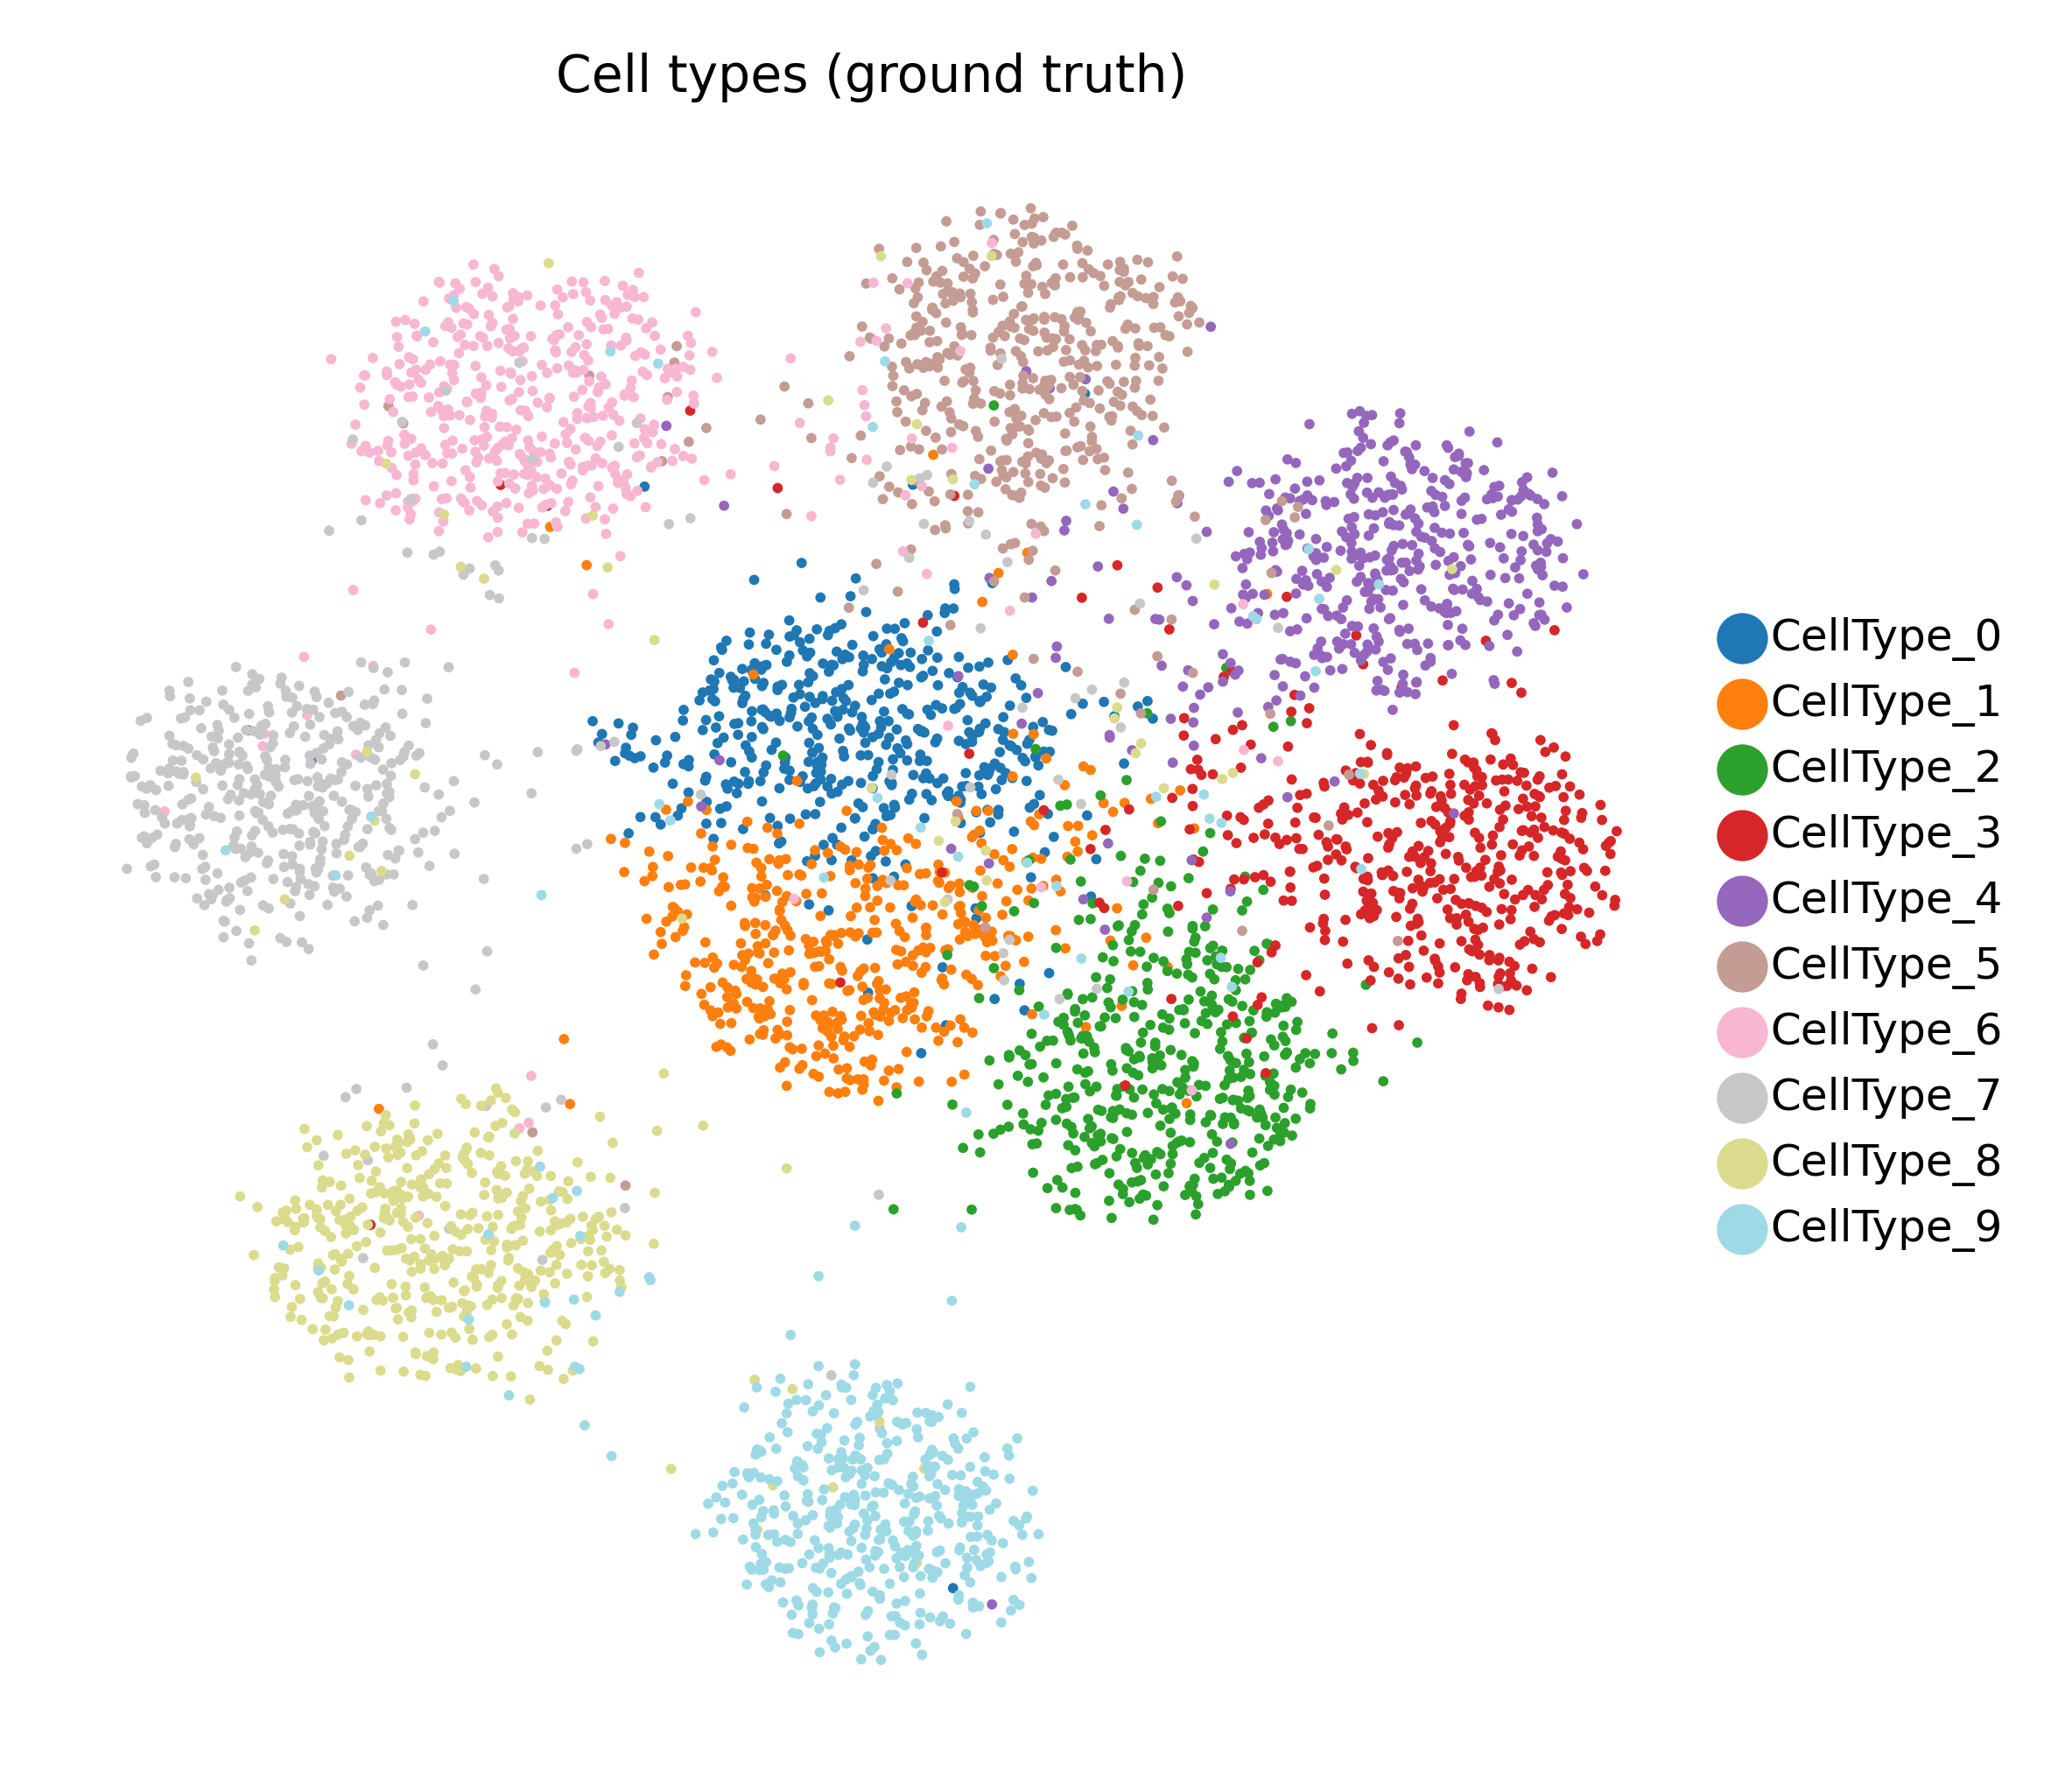

In [7]:
# Figure 1: UMAP cell types
sc.pl.umap(adp,color='Cell_Type',palette='tab20',size=8,frameon=False,title='Cell types (ground truth)',show=False)
save_fig('umap_cell_type'); plt.show()

saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/umap_condition_shift_nhood_20.png


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/umap_condition_shift_nhood_20.pdf


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/umap_condition_shift_nhood_20.svg


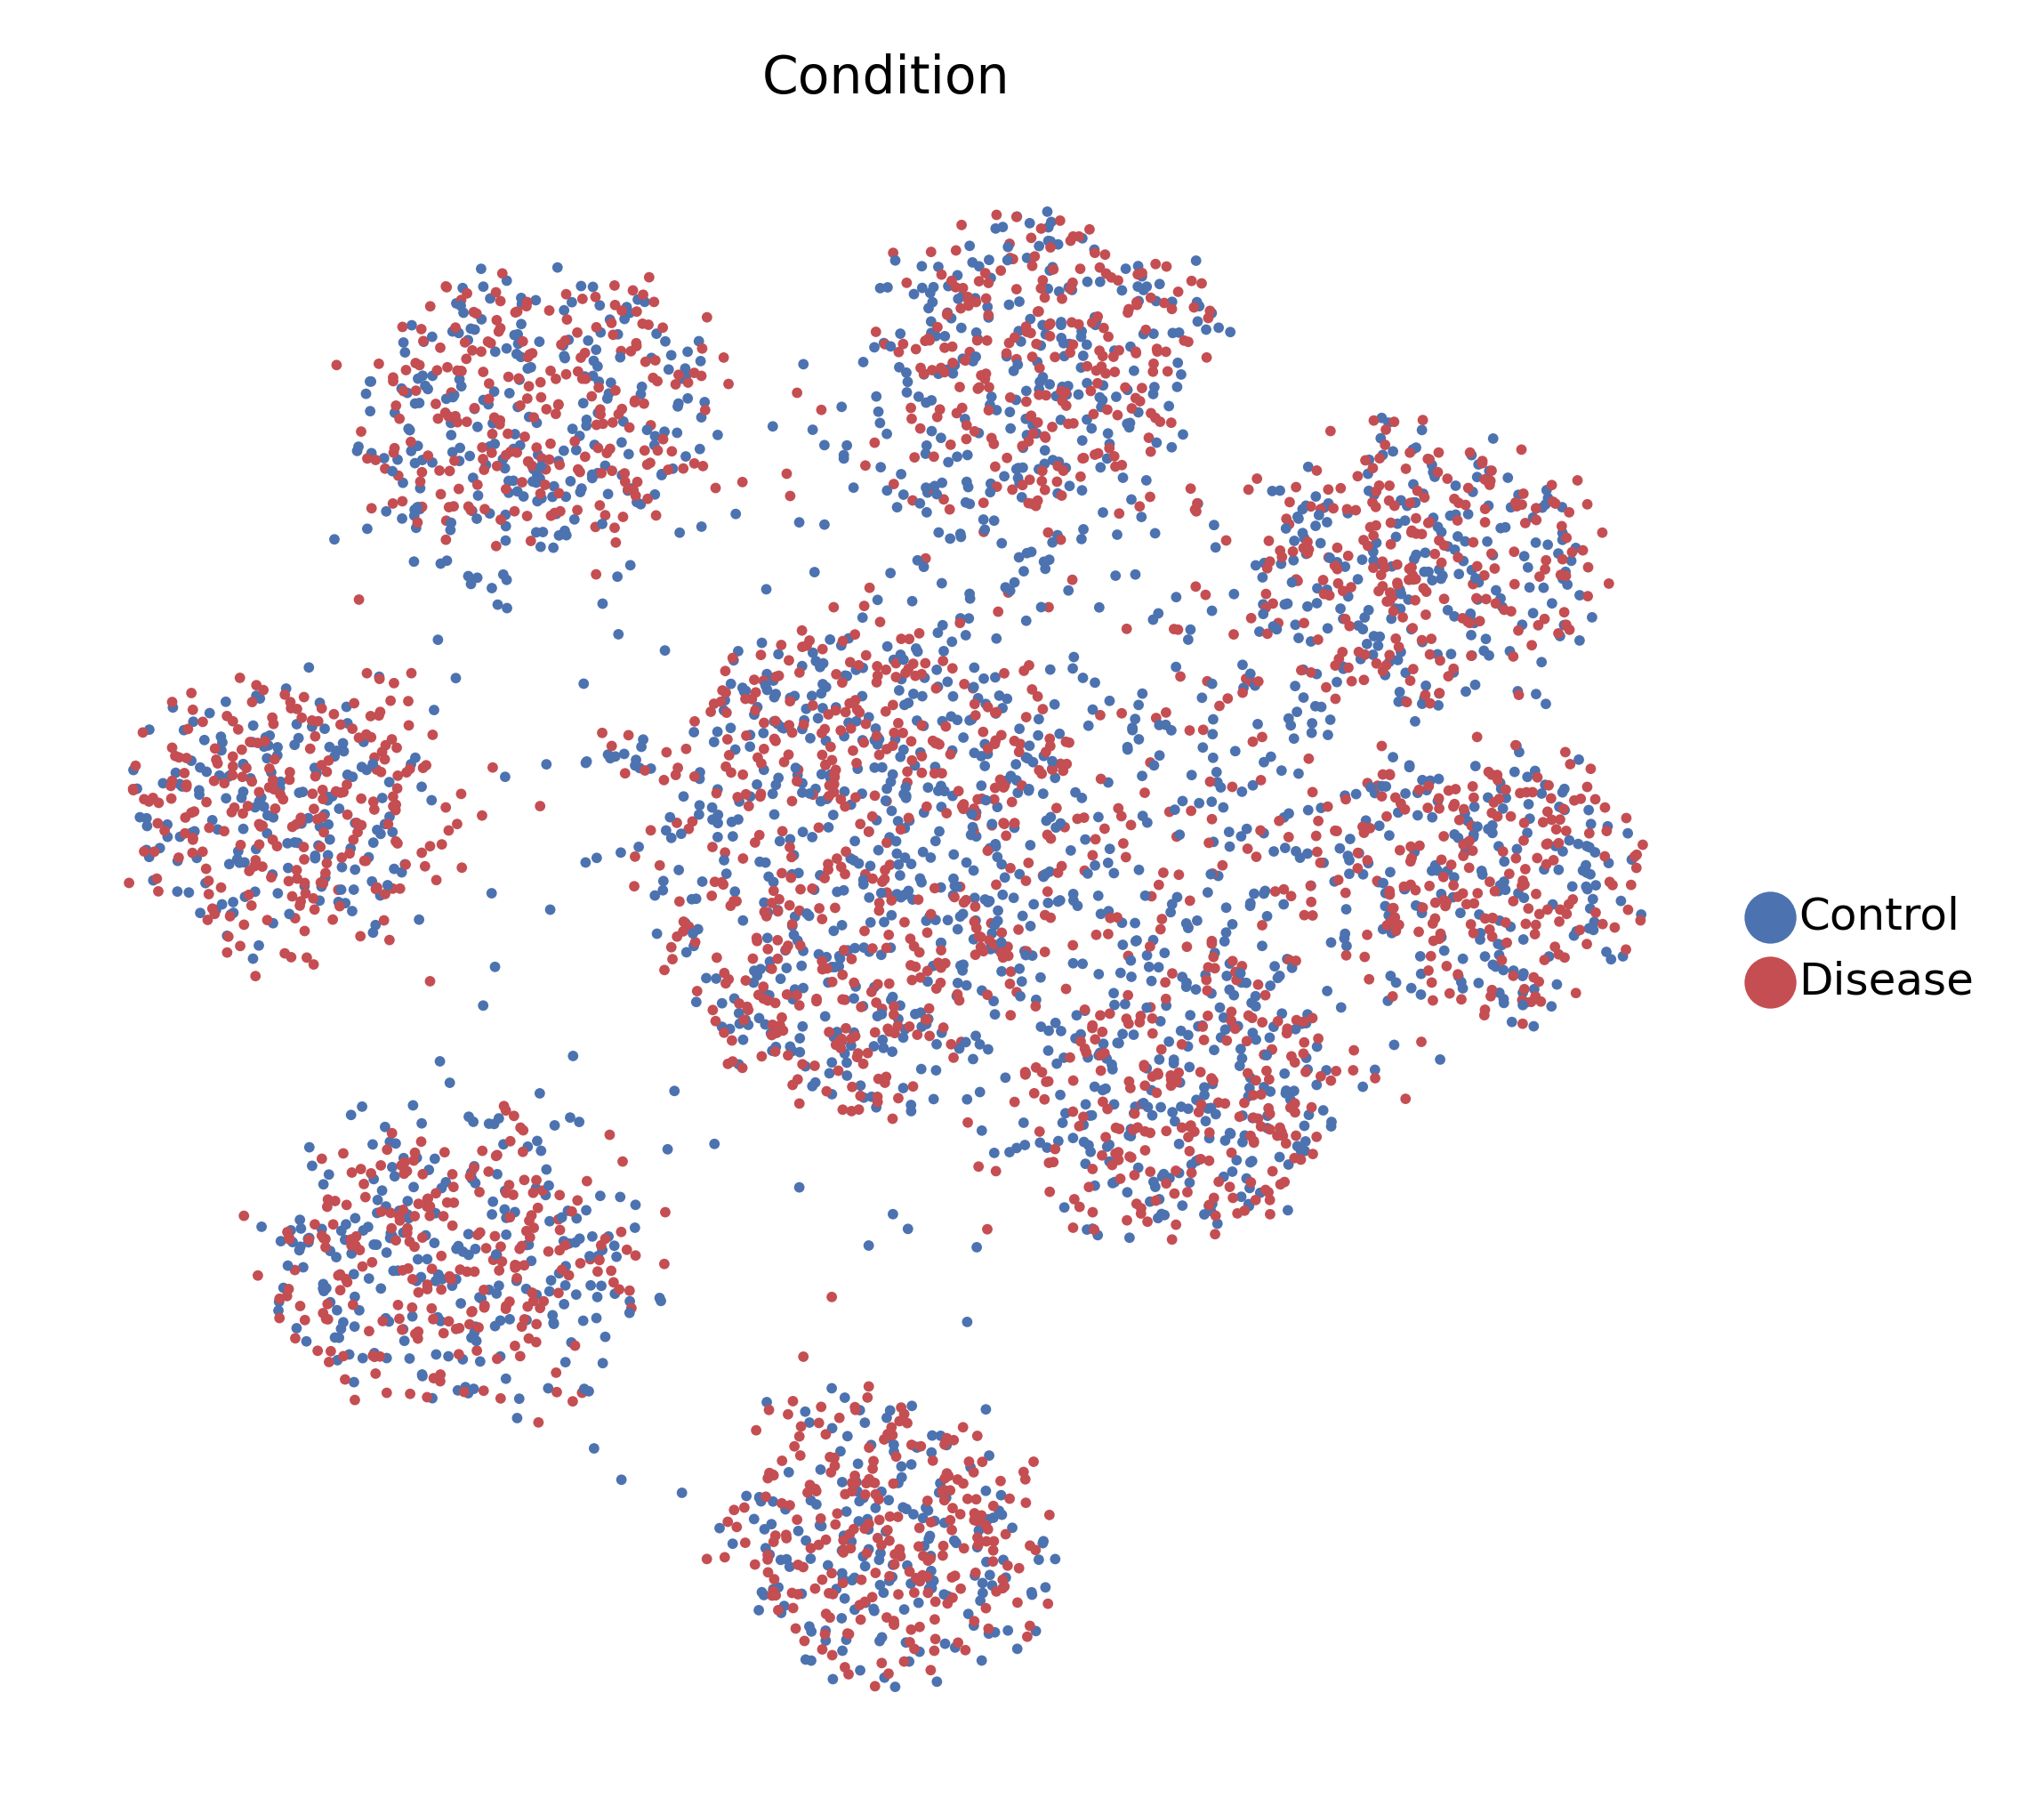

In [8]:
# Figure 2: UMAP condition (control + disease share each cell-type cluster)
sc.pl.umap(adp,color='condition',palette=['#4c72b0','#c44e52'],size=8,frameon=False,title='Condition',show=False)
save_fig('umap_condition'); plt.show()

In [9]:
# Figure 3: marker-loading boxplots (scCST scores gated by rra_directional_fdr<0.05, per DE-gene set, across cell types)
present=[g for v in marker_sets.values() for g in map(str,v) if g in name_to_idx]; present=list(dict.fromkeys(present))
mk_idx=[name_to_idx[g] for g in present]; col_of={g:j for j,g in enumerate(present)}
gs_m=gene_score[:,mk_idx]; sig_m=sig[:,mk_idx]; scores_gated=np.where(sig_m<SIG_THRESH,gs_m,0.0)
groups=list(pd.Categorical(adp.obs[GROUP_COL]).categories); group_vals=adp.obs[GROUP_COL].astype(str).values
set_names=list(marker_sets.keys()); MAX_PTS=4000; _rng=np.random.RandomState(0)
n_cols=3; n_rows=ceil(len(set_names)/n_cols)
fig,axes=plt.subplots(n_rows,n_cols,figsize=(4.2*n_cols,3.0*n_rows),sharey=True); axes=np.array(axes).flatten()
for idx,set_name in enumerate(set_names):
    ax=axes[idx]; cols=[col_of[str(g)] for g in marker_sets[set_name] if str(g) in col_of]; rows=[]
    for grp in groups:
        m=group_vals==grp; vals=scores_gated[np.ix_(m,cols)].ravel() if cols else np.array([])
        if vals.size>MAX_PTS: vals=vals[_rng.choice(vals.size,MAX_PTS,replace=False)]
        rows.append(pd.DataFrame({'Group':grp,'Score':vals}))
    dfg=pd.concat(rows,ignore_index=True)
    sns.boxplot(data=dfg,x='Group',y='Score',hue='Group',order=groups,palette='vlag',showfliers=False,linewidth=0.5,legend=False,ax=ax)
    ax.axhline(0,color='grey',linestyle='--',linewidth=0.6)
    ax.set_title(f'{set_name} ({len(marker_sets[set_name])} DE genes)'); ax.set_xlabel(''); ax.set_ylabel('Signed gene score' if idx%n_cols==0 else ''); ax.tick_params(axis='x',rotation=90)
for j in range(len(set_names),len(axes)): axes[j].axis('off')
fig.suptitle('scCST signed gene scores by DE-gene set (grouped by cell type)',y=1.01)
plt.tight_layout(); save_fig('marker_loading_boxplots',fig=fig); plt.show()

saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/marker_loading_boxplots_shift_nhood_20.png


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/marker_loading_boxplots_shift_nhood_20.pdf


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/marker_loading_boxplots_shift_nhood_20.svg


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/marker_heatmap_disease_shift_nhood_20.png


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/marker_heatmap_disease_shift_nhood_20.pdf


saved /path/to/data/scrna_seq/simulation_shift_realistic/figures/marker_heatmap_disease_shift_nhood_20.svg


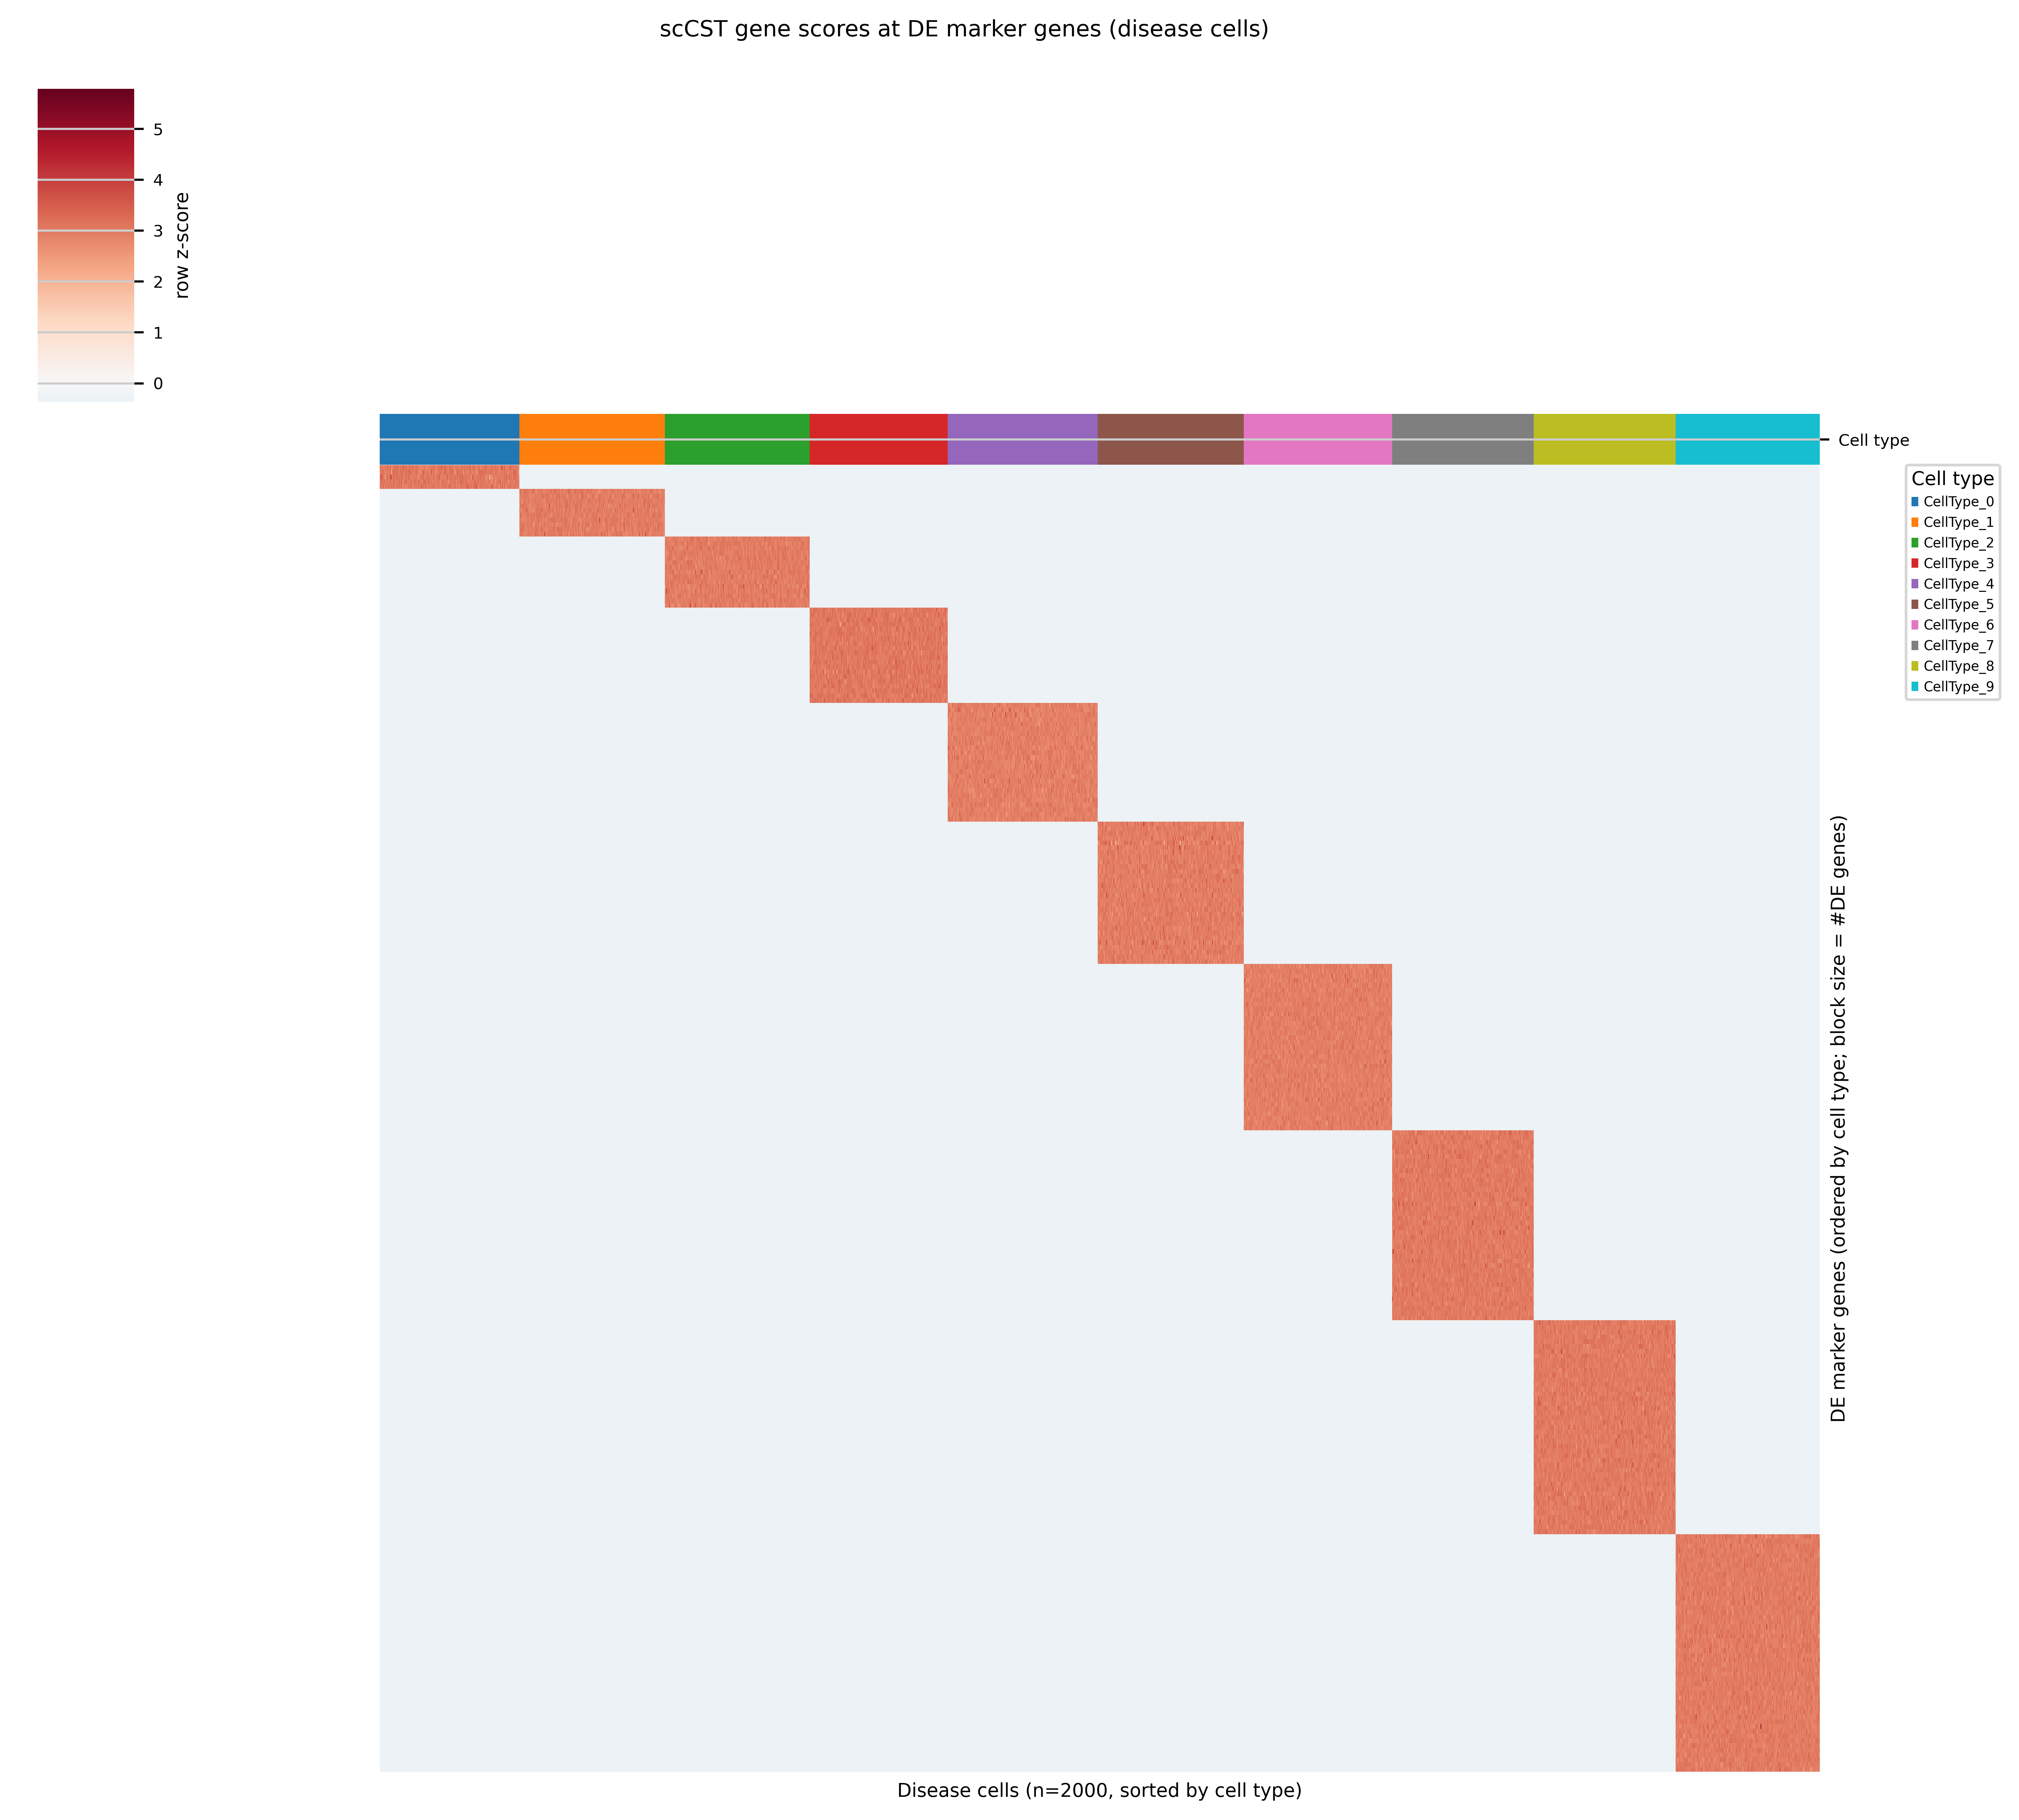

In [10]:
# Figure 4: marker heatmap (disease cells; block heights vary with #DE genes per type)
N_CELLS=2000; disease_mask=adp.obs['condition'].astype(str).values=='Disease'; dis_idx=np.where(disease_mask)[0]
if dis_idx.size>N_CELLS: dis_idx=np.sort(_rng.choice(dis_idx,N_CELLS,replace=False))
row_genes=[]
for grp in set_names:
    for g in map(str,marker_sets[grp]):
        if g in col_of: row_genes.append(g)
row_cols=[col_of[g] for g in row_genes]
cell_grp=adp.obs[GROUP_COL].astype(str).values[dis_idx]; order=np.argsort(cell_grp,kind='stable')
cells_ordered=dis_idx[order]; cell_grp_ordered=cell_grp[order]
mat=gs_m[np.ix_(cells_ordered,row_cols)].T
hm=pd.DataFrame(mat,index=row_genes,columns=[f'cell{i}' for i in range(len(cells_ordered))])
uniq_g=list(dict.fromkeys(cell_grp_ordered)); gcolors=dict(zip(uniq_g,sns.color_palette('tab10',len(uniq_g))))
col_colors=pd.Series([gcolors[g] for g in cell_grp_ordered],index=hm.columns,name='Cell type')
g=sns.clustermap(hm,cmap='RdBu_r',center=0,z_score=0,col_colors=col_colors,row_cluster=False,col_cluster=False,
    xticklabels=False,yticklabels=False,figsize=(10,9),cbar_kws={'label':'row z-score'})
g.ax_heatmap.set_xlabel(f'Disease cells (n={len(cells_ordered)}, sorted by cell type)')
g.ax_heatmap.set_ylabel('DE marker genes (ordered by cell type; block size = #DE genes)')
for coll in g.ax_heatmap.collections: coll.set_rasterized(True)
g.ax_heatmap.legend(handles=[Patch(facecolor=c,label=l) for l,c in gcolors.items()],title='Cell type',loc='upper left',bbox_to_anchor=(1.06,1),borderaxespad=0,fontsize=5)
g.figure.suptitle('scCST gene scores at DE marker genes (disease cells)',y=1.02)
save_fig('marker_heatmap_disease',fig=g.figure); plt.show()